# PCA Trajectory of FGSM Adversarial Attacks

This notebook visualizes how FGSM adversarial attacks move the internal representations of images within the neural network's latent space. We extract the high-dimensional feature vectors from the penultimate layer of the CNNs and use Principal Component Analysis (PCA) to project them into a 2D space, tracing the trajectory of the image as the attack strength ($\varepsilon$) increases.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Import models
from tensorflow.keras.applications import EfficientNetB0, InceptionV3, MobileNetV2

# Import specific preprocessing and decoding functions
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_eff
from tensorflow.keras.applications.inception_v3 import preprocess_input as preprocess_inc
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mob

In [2]:
# Dictionary with model configurations
models_dict = {
    'MobileNetV2': {
        'model': MobileNetV2(weights='imagenet'),
        'target_size': (224, 224),
        'preprocess_fn': preprocess_mob
    },
    'EfficientNetB0': {
        'model': EfficientNetB0(weights='imagenet'),
        'target_size': (224, 224),
        'preprocess_fn': preprocess_eff
    },
    'InceptionV3': {
        'model': InceptionV3(weights='imagenet'),
        'target_size': (299, 299),
        'preprocess_fn': preprocess_inc
    }
}

# Freeze weights as we only need to perform inference and compute gradients w.r.t inputs
for config in models_dict.values():
    config['model'].trainable = False

# Dictionary for target images
images_dict = {
    'Dog': '../images/dog.png',
    'Lion': '../images/lion.png'
}

In [3]:
def load_and_preprocess_image(img_path, target_size, preprocess_fn):
    img_raw = tf.io.read_file(img_path)
    img = tf.image.decode_image(img_raw, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, target_size)
    img = preprocess_fn(img) # Dynamic preprocessing
    img = tf.expand_dims(img, axis=0) # Add batch dimension
    return img

In [4]:
loss_object = tf.keras.losses.CategoricalCrossentropy()

def fgsm_attack(input_image, input_label, epsilon, current_model):
    with tf.GradientTape() as tape:
        tape.watch(input_image)
        prediction = current_model(input_image)
        loss = loss_object(input_label, prediction)
    
    # Get gradients of the loss w.r.t to the input image
    gradient = tape.gradient(loss, input_image)
    
    # Get the sign of the gradients
    signed_grad = tf.sign(gradient)
    
    # Create the adversarial image
    adv_image = input_image + epsilon * signed_grad
    return adv_image


LATENT SPACE TRAJECTORY (PCA): MobileNetV2



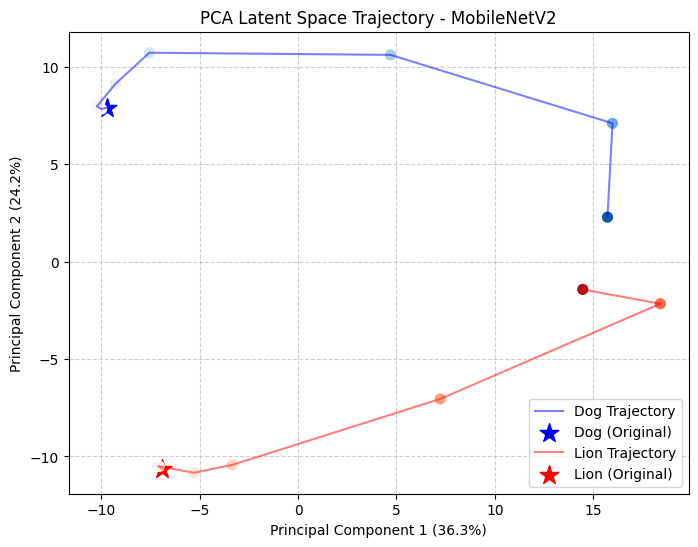


LATENT SPACE TRAJECTORY (PCA): EfficientNetB0



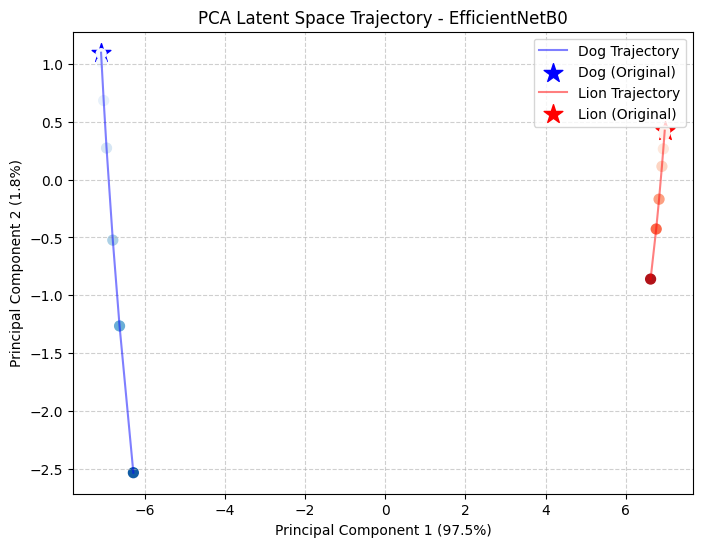


LATENT SPACE TRAJECTORY (PCA): InceptionV3



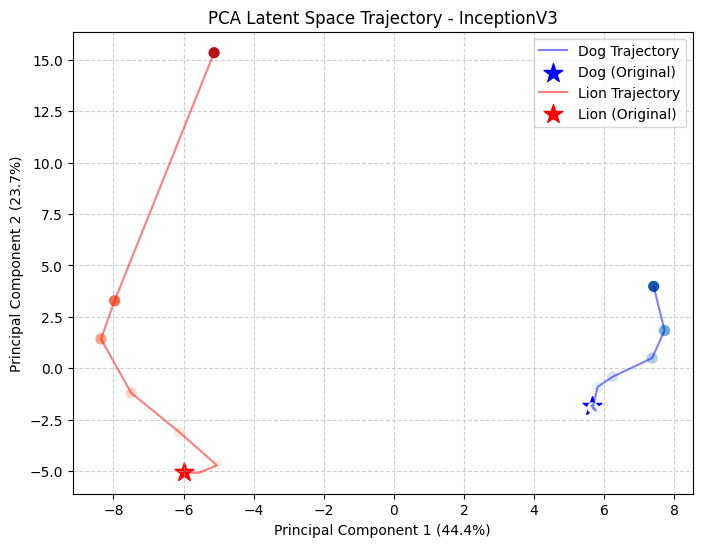

In [5]:
epsilons = [0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]

for model_name, m_config in models_dict.items():
    # Print a clear header when switching models
    print(f"\n{'='*80}")
    print(f"LATENT SPACE TRAJECTORY (PCA): {model_name}")
    print(f"{'='*80}\n")
    
    current_model = m_config['model']
    
    # Create a feature extractor model that outputs the penultimate layer (embeddings)
    feature_extractor = tf.keras.Model(inputs=current_model.input, outputs=current_model.layers[-1].input)
    
    # Dictionary to store the feature vectors
    features_data = {'Dog': [], 'Lion': []}
    
    for img_name, img_path in images_dict.items():
        input_img = load_and_preprocess_image(img_path, m_config['target_size'], m_config['preprocess_fn'])
        
        # Original prediction and feature extraction
        original_probs = current_model.predict(input_img, verbose=0)
        orig_features = feature_extractor.predict(input_img, verbose=0)
        features_data[img_name].append(orig_features.flatten())
        
        # Label for FGSM
        class_idx = tf.argmax(original_probs, axis=-1).numpy()[0]
        input_label = tf.reshape(tf.one_hot(class_idx, original_probs.shape[-1]), (1, -1))
        
        # Attack loop
        for epsilon in epsilons:
            adv_img = fgsm_attack(input_img, input_label, epsilon, current_model)
            adv_features = feature_extractor.predict(adv_img, verbose=0)
            features_data[img_name].append(adv_features.flatten())
            
    # Combine all features to fit a shared PCA space
    all_features = np.array(features_data['Dog'] + features_data['Lion'])
    
    # Fit PCA (Reduce from ~1280 dimensions to 2)
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(all_features)
    
    # Split results back
    num_points = len(epsilons) + 1
    dog_pca = pca_result[:num_points]
    lion_pca = pca_result[num_points:]
    
    # Plotting
    plt.figure(figsize=(8, 6))
    
    # Plot Dog Trajectory
    plt.plot(dog_pca[:, 0], dog_pca[:, 1], 'b-', alpha=0.5, label='Dog Trajectory')
    plt.scatter(dog_pca[0, 0], dog_pca[0, 1], c='blue', marker='*', s=200, label='Dog (Original)')
    plt.scatter(dog_pca[1:, 0], dog_pca[1:, 1], c=epsilons, cmap='Blues', vmin=0, vmax=0.6, s=50)
    
    # Plot Lion Trajectory
    plt.plot(lion_pca[:, 0], lion_pca[:, 1], 'r-', alpha=0.5, label='Lion Trajectory')
    plt.scatter(lion_pca[0, 0], lion_pca[0, 1], c='red', marker='*', s=200, label='Lion (Original)')
    plt.scatter(lion_pca[1:, 0], lion_pca[1:, 1], c=epsilons, cmap='Reds', vmin=0, vmax=0.6, s=50)
    
    plt.title(f'PCA Latent Space Trajectory - {model_name}')
    plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()